# How far ahead does the MILP need to look?

The *same* continuous MILP formulation, driven ten different ways over the same 30 kWh
battery and the same GEN-I Dinamični samooskrba tariff, on 40 households — **5 from each of
the 8 Fluvius groups** (plain, EV, HP, HP+EV, PV, PV+EV, PV+HP, PV+HP+EV), full year.

Each strategy is a combination of three choices:

| | |
|---|---|
| **horizon** | how far each solve sees: day (96 intervals), week (672), month, or the whole year |
| **execution** | `block` — carry out the entire plan, then re-plan · `receding` — carry out the first interval only, then re-plan (MPC) |
| **SOC mode** | `fixed50` — every solve starts *and* ends at 50 % of capacity · `carry` — only the first period starts at 50 %, then each period ends wherever it likes and the next starts from exactly that state of charge |

The `carry` family is what removes the artificial "hand the battery back at 15 kWh every
midnight" constraint. The two families are reported side by side, not as replacements.

`week_receding` and `week_receding_carry` are commented out in `Horizon_Comparison.STRATEGIES`
— at 35 136 solves of 672 intervals each they cost ~3 h per household, for a result the
earlier 30-household run already showed (95.0 % of the achievable saving, only 0.8 points
better than the 19-second `week_block`).

### Three things that make the comparison fair

**The MILP only produces a dispatch.** Every executed trajectory is priced afterwards by one
shared evaluator (`price_interval`) walking interval by interval with a single running peak
state. The excess-power (konica) charge is a running maximum over the whole year, so no
strategy may price its own peaks. Checked against `run_milp_benchmark`'s internal pricing on a
one-week solve: identical to 0.00e+00 EUR.

**The controller knows its true peak state.** `_PeakSeedView` replaces the environment's
no-battery peak seed with the peak the executed trajectory has actually set.

**The year is always closed at 50 %.** Under *both* SOC modes the run starts at 15 kWh and the
final period must end at 15 kWh — otherwise a free-terminal strategy would simply sell off its
opening charge and book it as a saving. Only the *interior* boundaries differ between the
families. A useful consequence: `full_period_carry` has just one period, so it must come out
exactly equal to `full_period`, and that identity is visible in the table below.

In [6]:
### Imports
import time
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import importlib
import Horizon_Comparison as hc
hc = importlib.reload(hc)

print("Horizon_Comparison loaded.")

Horizon_Comparison loaded.


## 1. Configuration

The study parameters live in `Horizon_Comparison.py` so the notebook and the batch script
cannot drift apart. `RUN_BATCH = True` recomputes everything — ~1.2 h per household-unit,
~5 h for all 40 on 10 workers — so by default the notebook reads the CSVs the batch already
wrote.

In [9]:
UNITS = hc.study_units()          # (dataset group, household id) pairs
RESULTS_DIR = hc.RESULTS_DIR
RUN_BATCH = False                 # True -> recompute (~5 h on 10 workers, resumable)
N_WORKERS = 10

print(f"groups             : {', '.join(hc.DATASET_GROUPS)}")
print(f"households         : {hc.HOUSEHOLDS_PER_GROUP} per group = {len(UNITS)} units")
print(f"tariff             : {hc.PAKET_ID} ({hc.PRICING_SCHEME}), regime {hc.PRICING_REFERENCE_YEAR}")
print(f"battery            : {hc.BATTERY_CAPACITY_KWH:.0f} kWh, "
      f"{min(hc.C_RATE * hc.BATTERY_CAPACITY_KWH, hc.INVERTER_MAX_KW):.1f} kW, "
      f"eff {hc.CHARGE_EFFICIENCY:.2f}/{hc.DISCHARGE_EFFICIENCY:.2f}")
print(f"SOC                : start {hc.SOC_FRACTION:.0%}, "
      f"final period ends at {hc.SOC_FRACTION:.0%}; interior boundaries per SOC mode")
print(f"peak reset         : {hc.PEAK_RESET_MONTHS} (None = one annual ratchet)")
print(f"strategies         : {len(hc.STRATEGIES)}")
for name, (horizon, execution, soc_mode) in hc.STRATEGIES.items():
    print(f"   {name:20s} horizon={horizon:7s} execution={execution:9s} soc={soc_mode}")

groups             : Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV, Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV
households         : 5 per group = 40 units
tariff             : GENI_SAMO_DINAMICNI (si_samooskrba), regime 2026
battery            : 30 kWh, 11.0 kW, eff 0.95/0.95
SOC                : start 50%, final period ends at 50%; interior boundaries per SOC mode
peak reset         : None (None = one annual ratchet)
strategies         : 5
   day_block            horizon=day     execution=block     soc=fixed50
   day_receding         horizon=day     execution=receding  soc=fixed50
   week_block           horizon=week    execution=block     soc=fixed50
   month_block          horizon=month   execution=block     soc=fixed50
   full_period          horizon=period  execution=block     soc=fixed50


## 2. Load results

In [10]:
if RUN_BATCH:
    hc.run_batch(UNITS, output_dir=RESULTS_DIR, n_workers=N_WORKERS)

df_all = hc.collect_results(RESULTS_DIR)
if df_all.empty:
    raise SystemExit(
        f"No results in {RESULTS_DIR}.\n"
        f"Run  python Horizon_Comparison.py --per-group 5 --workers 10  (~5 h), "
        f"or set RUN_BATCH = True above."
    )

# The batch writes each unit's CSV after every finished strategy, so this notebook
# is readable at any point during the run.
expected = list(hc.STRATEGIES)
done = {k: set(g) for k, g in df_all.groupby(hc.KEY_COLUMNS)["Strategy"]}
complete = [k for k, s in done.items() if set(expected) <= s]

print(f"{len(complete)} of {len(UNITS)} household-units complete "
      f"({len(df_all)} of {len(UNITS) * len(expected)} runs finished)")
if len(complete) < len(done):
    progress = pd.DataFrame(
        [[("done" if s in done[k] else "-") for s in expected] for k in sorted(done)],
        index=pd.MultiIndex.from_tuples(sorted(done), names=hc.KEY_COLUMNS),
        columns=expected,
    )
    print("\nBatch still in flight:")
    print(progress.to_string())

if not complete:
    raise SystemExit(
        "No household-unit has every strategy yet, so there is nothing to compare against "
        "the whole-year optimum. Re-run this notebook once the batch has finished a unit "
        "(~1.2 h each)."
    )

# Only fully solved units enter the comparison, so every row of the table is
# averaged over the same set of households.
keys = pd.MultiIndex.from_tuples(complete, names=hc.KEY_COLUMNS)
df_all = df_all.set_index(hc.KEY_COLUMNS).loc[keys].reset_index()
print(f"\nComparing {len(complete)} units x {len(expected)} strategies = {len(df_all)} runs, "
      f"{df_all['N_Solves'].sum():,.0f} MILP solves, "
      f"{df_all['Runtime_s'].sum() / 3600:.1f} solver-hours.")
print(f"Max SOC drift over every run: {df_all['SOC_Drift_kWh'].max():.2e} kWh "
      f"(0 means no solve ever ended infeasible)")

  [Fluvius_EV 5] day_receding            263.61 EUR  ( 35135 solves,  1924.7 s)
  [Fluvius_EV 2] day_receding           1122.42 EUR  ( 35135 solves,  1926.0 s)
  [Fluvius 5] day_receding           -260.48 EUR  ( 35135 solves,  1937.1 s)
  [Fluvius 1] day_receding            -44.38 EUR  ( 35135 solves,  1942.8 s)
  [Fluvius_EV 5] week_block              260.95 EUR  (    53 solves,    19.5 s)
  [Fluvius 2] day_receding            -22.67 EUR  ( 35135 solves,  1945.6 s)
  [Fluvius_EV 2] week_block             1113.06 EUR  (    53 solves,    19.7 s)
  [Fluvius 4] day_receding             19.42 EUR  ( 35135 solves,  1948.3 s)
  [Fluvius 3] day_receding             47.00 EUR  ( 35135 solves,  1950.6 s)
  [Fluvius_EV 1] day_receding             95.11 EUR  ( 35135 solves,  1954.4 s)
  [Fluvius_EV 3] day_receding            183.52 EUR  ( 35135 solves,  1955.4 s)
  [Fluvius_EV 4] day_receding            538.23 EUR  ( 35135 solves,  1956.3 s)
  [Fluvius 5] week_block             -287.79 EUR  (    

## 3. The comparison table

The headline number is **`Gap_pct`** — the share of the *achievable* saving a strategy throws
away by not seeing the whole year:

    Gap_pct = 100 % − (no-battery cost − strategy cost) / (no-battery cost − whole-year optimum)

so `full_period` is 0 % by construction and bigger is worse. Reporting it this way makes the
40 households comparable to each other: their absolute bills differ by an order of magnitude
(a 2 MWh/a household against a 16 MWh/a heat-pump-plus-EV one), but the fraction of the
attainable benefit each strategy secures does not depend on that scale.

In [11]:
summary, df_scored = hc.summarize(df_all)
summary_display = summary.rename(columns={
    "SOC_Mode": "SOC mode",
    "Gap_pct": "Gap [%]",
    "Worst_Gap_pct": "Worst unit [%]",
    "Best_Gap_pct": "Best unit [%]",
    "Gap_EUR": "Gap [EUR/a]",
    "Cost_EUR": "Cost [EUR/a]",
    "Savings_EUR": "Saving [EUR/a]",
    "Cycles": "Full cycles/a",
    "Peak_kW": "Peak import [kW]",
    "Solves": "MILP solves",
    "Runtime_s": "Solver time [s]",
})
summary_display.round(2)

,Units,SOC mode,Gap [%],Worst unit [%],Best unit [%],Gap [EUR/a],Cost [EUR/a],Saving [EUR/a],Full cycles/a,Peak import [kW],MILP solves,Solver time [s]
Strategy,,,,,,,,,,,,
day_block,40,fixed50,16.39,24.58,11.04,119.23,396.77,621.76,256.64,15.30,366.0,23.08
day_receding,40,fixed50,6.58,14.42,0.79,46.78,324.32,694.21,242.97,15.16,35135.0,1977.96
week_block,40,fixed50,5.06,9.85,1.30,36.21,313.76,704.78,251.00,15.10,53.0,20.09
month_block,40,fixed50,2.00,3.32,0.68,14.46,292.01,726.53,254.90,14.99,12.0,36.23
full_period,40,fixed50,-0.00,0.00,-0.00,0.00,277.54,740.99,262.81,15.29,1.0,93.25


In [12]:
### Mean gap [%] per dataset group
by_group = hc.summarize_by_group(df_scored)
by_group.round(2)

Strategy,day_block,day_receding,week_block,month_block,full_period
Dataset,,,,,
Fluvius,22.20,12.36,8.73,3.04,0.0
Fluvius_EV,18.00,7.62,5.95,2.27,-0.0
Fluvius_HP,16.76,8.29,5.76,2.13,-0.0
Fluvius_HP_EV,13.43,2.99,2.95,1.35,0.0
Fluvius_PV,17.95,8.15,5.80,2.22,-0.0
Fluvius_PV_EV,14.86,4.41,3.71,1.64,0.0
Fluvius_PV_HP,15.03,5.19,4.42,1.98,0.0
Fluvius_PV_HP_EV,12.88,3.61,3.20,1.41,0.0


In [13]:
### Every household-unit, gap to the whole-year optimum [%]
per_unit = (
    df_scored.pivot_table(index=hc.KEY_COLUMNS, columns="Strategy", values="Gap_pct")
    .reindex(columns=[s for s in hc.STRATEGIES if s in set(df_scored["Strategy"])])
)
per_unit.round(2)

Strategy                    day_block  day_receding  week_block  month_block  \
Dataset          Household                                                     
Fluvius          1              22.36         12.79        8.79         3.07   
                 2              22.08         12.10        8.74         3.06   
                 3              20.04          9.98        7.55         2.68   
                 4              21.95         12.53        8.73         3.07   
                 5              24.58         14.42        9.85         3.32   
Fluvius_EV       1              20.10         10.12        7.68         2.76   
                 2              16.20          4.58        3.30         1.45   
                 3              20.35         10.97        8.05         2.88   
                 4              17.22          7.29        5.95         2.28   
                 5              16.13          5.12        4.75         1.96   
Fluvius_HP       1              13.85          5.86        4.81         2.10   
                 2              16.38          7.64        5.80         1.98   
                 3              19.75          9.28        6.20         2.25   
                 4              19.06         12.78        7.53         2.71   
                 5              14.74          5.87        4.44         1.64   
Fluvius_HP_EV    1              13.26          1.13        1.30         0.71   
                 2              11.95          2.45        2.11         1.00   
                 3              11.04          1.10        1.63         0.96   
                 4              15.04          4.09        4.02         1.90   
                 5              15.86          6.16        5.68         2.16   
Fluvius_PV       1              14.66          5.30        3.97         1.88   
                 2              17.93          8.15        5.74         2.11   
                 3              19.10         10.01        6.73         2.29   
                 4              21.66         11.31        8.03         2.75   
                 5              16.40          5.98        4.51         2.06   
Fluvius_PV_EV    1              11.40          1.21        1.49         0.85   
                 2              19.95          8.92        6.94         2.67   
                 3              12.08          1.26        1.61         0.76   
                 4              16.68          6.80        5.21         2.09   
                 5              14.19          3.84        3.31         1.83   
Fluvius_PV_HP    1              13.09          3.46        3.26         1.67   
                 2              14.74          5.54        4.57         2.02   
                 3              15.49          6.88        5.38         2.17   
                 4              17.39          5.63        5.36         2.18   
                 5              14.45          4.46        3.54         1.85   
Fluvius_PV_HP_EV 1              14.08          4.31        3.99         1.88   
                 2              11.91          3.10        2.62         1.26   
                 3              11.29          0.79        1.35         0.68   
                 4              15.01          6.66        5.55         1.95   
                 5              12.10          3.17        2.47         1.31   

Strategy                    full_period  
Dataset          Household               
Fluvius          1                  0.0  
                 2                  0.0  
                 3                  0.0  
                 4                  0.0  
                 5                  0.0  
Fluvius_EV       1                 -0.0  
                 2                  0.0  
                 3                  0.0  
                 4                 -0.0  
                 5                  0.0  
Fluvius_HP       1                  0.0  
                 2                 -0.0  
                 3                  0.0  
         

## 4. Plots

All of these read in percent of the achievable saving, so households of very different size
can sit on the same axis.

In [14]:
### Shared chart styling
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
BLUE_RAMP = LinearSegmentedColormap.from_list("blues", BLUES)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})

STRAT_ORDER = [s for s in hc.STRATEGIES if s in set(df_scored["Strategy"])]
LABEL = {
    "day_block": "day, block",
    "day_receding": "day, receding",
    "week_block": "week, block",
    "week_receding": "week, receding",
    "month_block": "month, block",
    "full_period": "whole year",
    "day_block_carry": "day, block",
    "day_receding_carry": "day, receding",
    "week_block_carry": "week, block",
    "week_receding_carry": "week, receding",
    "month_block_carry": "month, block",
    "full_period_carry": "whole year",
}
MODE_COLOR = {"fixed50": SERIES[0], "carry": SERIES[1]}
MODE_LABEL = {"fixed50": "SOC pinned to 50 % every period",
              "carry": "SOC carried across periods"}
print("Style ready.")

Style ready.


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


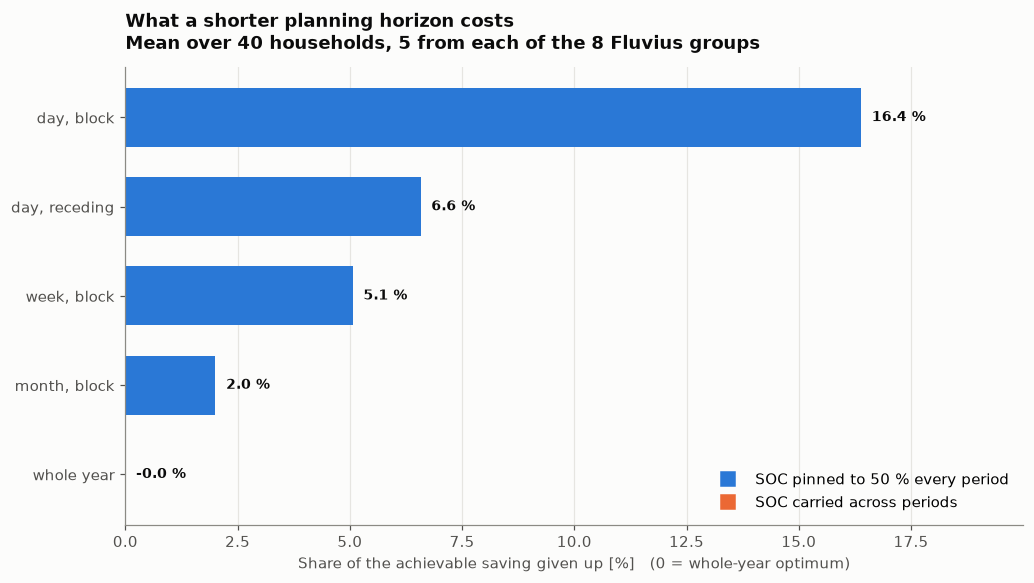

In [15]:
### What a shorter planning horizon costs, in % of the achievable saving
fig, ax = plt.subplots(figsize=(9.5, 5.4))

gaps = summary.loc[STRAT_ORDER, "Gap_pct"]
modes = summary.loc[STRAT_ORDER, "SOC_Mode"]
ypos = np.arange(len(STRAT_ORDER))[::-1]

ax.barh(ypos, gaps, height=0.66, color=[MODE_COLOR[m] for m in modes])
for y, gap_v in zip(ypos, gaps):
    ax.annotate(f"{gap_v:.1f} %", xy=(gap_v, y), xytext=(7, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9, fontweight="semibold")

ax.axvline(0, color=MUTED, lw=1.1, ls="--")
ax.set_yticks(ypos, [LABEL[s] for s in STRAT_ORDER])
ax.set_xlim(0, max(float(gaps.max()) * 1.22, 1.0))
ax.set_xlabel("Share of the achievable saving given up [%]   (0 = whole-year optimum)")
ax.set_title("What a shorter planning horizon costs\n"
             f"Mean over {int(summary['Units'].iloc[0])} households, "
             "5 from each of the 8 Fluvius groups")
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], marker="s", ls="", ms=9, color=MODE_COLOR[m]) for m in MODE_COLOR]
ax.legend(handles, [MODE_LABEL[m] for m in MODE_COLOR], loc="lower right")
plt.tight_layout()
plt.show()

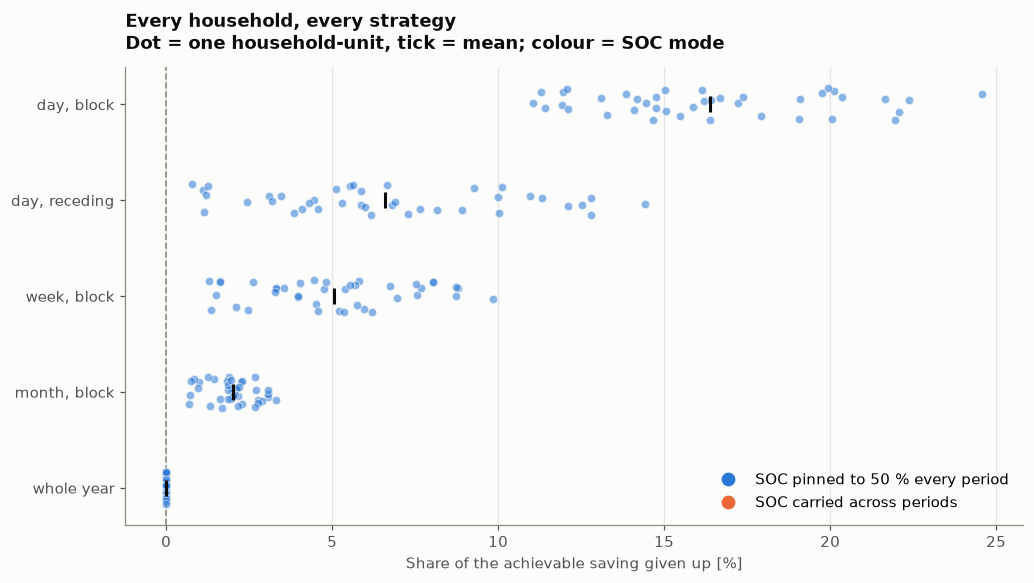

In [16]:
### Spread across households: one dot per household-unit
fig, ax = plt.subplots(figsize=(9.5, 5.4))

rng = np.random.default_rng(0)
for i, strat in enumerate(STRAT_ORDER):
    y = len(STRAT_ORDER) - 1 - i
    vals = df_scored.loc[df_scored["Strategy"] == strat, "Gap_pct"]
    colour = MODE_COLOR[hc.STRATEGIES[strat][2]]
    ax.scatter(vals, y + rng.uniform(-0.17, 0.17, len(vals)), s=30,
               color=colour, alpha=0.55, lw=0.7, edgecolor=SURFACE, zorder=3)
    ax.scatter([vals.mean()], [y], s=120, marker="|", color=INK, lw=2.0, zorder=4)

ax.axvline(0, color=MUTED, lw=1.1, ls="--")
ax.set_yticks(np.arange(len(STRAT_ORDER))[::-1], [LABEL[s] for s in STRAT_ORDER])
ax.set_xlabel("Share of the achievable saving given up [%]")
ax.set_title("Every household, every strategy\n"
             "Dot = one household-unit, tick = mean; colour = SOC mode")
ax.grid(axis="y", visible=False)
handles = [plt.Line2D([], [], marker="o", ls="", ms=8, color=MODE_COLOR[m]) for m in MODE_COLOR]
ax.legend(handles, [MODE_LABEL[m] for m in MODE_COLOR], loc="lower right")
plt.tight_layout()
plt.show()

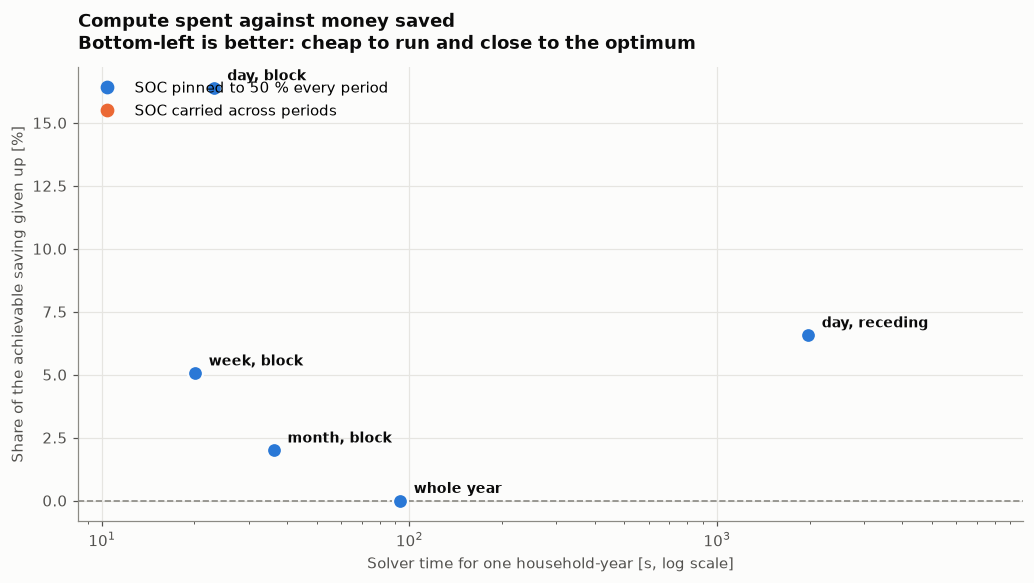

In [17]:
### What the extra compute buys
fig, ax = plt.subplots(figsize=(9.5, 5.4))

x = summary.loc[STRAT_ORDER, "Runtime_s"]
y = summary.loc[STRAT_ORDER, "Gap_pct"]
for strat, xi, yi in zip(STRAT_ORDER, x, y):
    colour = MODE_COLOR[hc.STRATEGIES[strat][2]]
    ax.scatter([xi], [yi], s=95, color=colour, zorder=3, lw=1.4, edgecolor=SURFACE)
    ax.annotate(LABEL[strat], xy=(xi, yi), xytext=(9, 5), textcoords="offset points",
                color=INK, fontsize=9, fontweight="semibold")

ax.set_xscale("log")
ax.set_xlim(float(x.min()) / 2.4, float(x.max()) * 5.0)
ax.axhline(0, color=MUTED, lw=1.1, ls="--")
ax.set_xlabel("Solver time for one household-year [s, log scale]")
ax.set_ylabel("Share of the achievable saving given up [%]")
ax.set_title("Compute spent against money saved\n"
             "Bottom-left is better: cheap to run and close to the optimum")
handles = [plt.Line2D([], [], marker="o", ls="", ms=8, color=MODE_COLOR[m]) for m in MODE_COLOR]
ax.legend(handles, [MODE_LABEL[m] for m in MODE_COLOR], loc="upper left")
plt.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


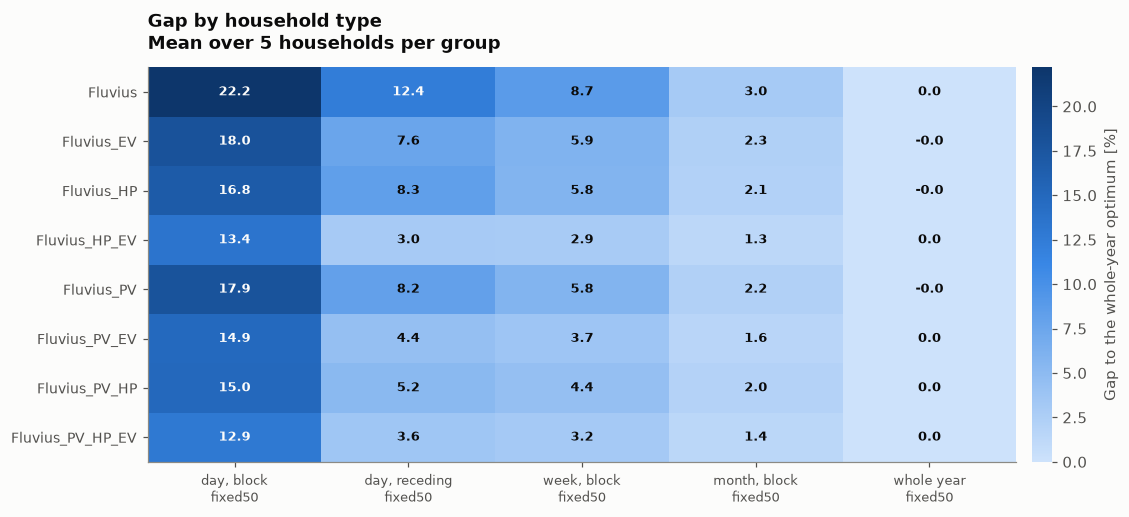

In [18]:
### Does the household type change the answer?
plot_cols = [s for s in STRAT_ORDER if s != "full_period_carry"]
matrix = by_group[plot_cols]

fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(matrix.to_numpy(), cmap=BLUE_RAMP, aspect="auto", vmin=0)

ax.set_xticks(range(len(plot_cols)),
              [f"{LABEL[s]}\n{hc.STRATEGIES[s][2]}" for s in plot_cols], fontsize=8.5)
ax.set_yticks(range(len(matrix.index)), matrix.index, fontsize=9)
ax.grid(visible=False)

values = matrix.to_numpy()
vmax = float(np.nanmax(values))
for r in range(values.shape[0]):
    for c in range(values.shape[1]):
        v = values[r, c]
        ax.annotate(f"{v:.1f}", xy=(c, r), ha="center", va="center", fontsize=8.5,
                    color=SURFACE if v > 0.55 * vmax else INK, fontweight="semibold")

cbar = fig.colorbar(im, ax=ax, pad=0.015)
cbar.set_label("Gap to the whole-year optimum [%]", color=INK_2)
cbar.outline.set_visible(False)
ax.set_title("Gap by household type\n"
             f"Mean over {hc.HOUSEHOLDS_PER_GROUP} households per group")
plt.tight_layout()
plt.show()

## 5. Read-out

In [19]:
fixed = [s for s in STRAT_ORDER if hc.STRATEGIES[s][2] == "fixed50"]
non_optimal = [s for s in STRAT_ORDER if summary.loc[s, "Gap_pct"] > 1e-9]
best = summary.loc[non_optimal, "Gap_pct"].idxmin() if non_optimal else STRAT_ORDER[0]

lines = [
    f"{int(summary['Units'].iloc[0])} household-units "
    f"({hc.HOUSEHOLDS_PER_GROUP} x {len(hc.DATASET_GROUPS)} Fluvius groups), "
    f"{hc.BATTERY_CAPACITY_KWH:.0f} kWh battery, full year",
    "",
    f"{'strategy':16s}{'SOC mode':10s}{'gap %':>8s}{'worst':>8s}{'gap EUR/a':>11s}"
    f"{'solves':>9s}{'time':>9s}",
]
for strat in STRAT_ORDER:
    r = summary.loc[strat]
    lines.append(
        f"{LABEL[strat]:16s}{r['SOC_Mode']:10s}{r['Gap_pct']:7.2f}%{r['Worst_Gap_pct']:7.2f}%"
        f"{r['Gap_EUR']:11.2f}{r['Solves']:9,.0f}{r['Runtime_s']:8.0f}s"
    )

lines += ["", "Same horizon and execution, the two SOC modes side by side:"]
for a in fixed:
    b = f"{a}_carry"
    if b in summary.index:
        delta = summary.loc[b, "Gap_pct"] - summary.loc[a, "Gap_pct"]
        verdict = ("identical" if abs(delta) <= 0.005
                   else "carry is worse" if delta > 0 else "carry is better")
        lines.append(f"   {LABEL[a]:16s} {summary.loc[a, 'Gap_pct']:6.2f}% -> "
                     f"{summary.loc[b, 'Gap_pct']:6.2f}%  ({delta:+.2f} pts, {verdict})")

lines += ["", "Longer horizon, same execution and SOC mode:"]
for a, b in (("day_block", "week_block"), ("week_block", "month_block"),
             ("month_block", "full_period"),
             ("day_block_carry", "week_block_carry"),
             ("week_block_carry", "month_block_carry")):
    if a in summary.index and b in summary.index:
        lines.append(f"   {LABEL[a]:16s} -> {LABEL[b]:16s} "
                     f"{summary.loc[a, 'Gap_pct'] - summary.loc[b, 'Gap_pct']:+6.2f} pts "
                     f"({hc.STRATEGIES[a][2]})")

lines += ["", "Re-planning every interval instead of committing to the block:"]
for a, b in (("day_block", "day_receding"), ("day_block_carry", "day_receding_carry")):
    if a in summary.index and b in summary.index:
        lines.append(f"   {LABEL[a]:16s} {hc.STRATEGIES[a][2]:8s} "
                     f"{summary.loc[a, 'Gap_pct']:6.2f}% -> {summary.loc[b, 'Gap_pct']:6.2f}%  "
                     f"({summary.loc[b, 'Solves'] / summary.loc[a, 'Solves']:.0f}x the solves, "
                     f"{summary.loc[b, 'Runtime_s'] / summary.loc[a, 'Runtime_s']:.0f}x the time)")

lines += ["", f"Best non-clairvoyant strategy: {LABEL[best]} ({hc.STRATEGIES[best][2]}), "
              f"{summary.loc[best, 'Gap_pct']:.2f} % short of the optimum"]

spread = by_group.max(axis=0) - by_group.min(axis=0)
lines += ["", "Spread of the mean gap across the 8 household types [pts]:"]
for strat in STRAT_ORDER:
    if strat in spread.index and spread[strat] > 1e-9:
        lines.append(f"   {LABEL[strat]:16s} {hc.STRATEGIES[strat][2]:8s} {spread[strat]:5.2f}")

print("\n".join(lines))

40 household-units (5 x 8 Fluvius groups), 30 kWh battery, full year

strategy        SOC mode     gap %   worst  gap EUR/a   solves     time
day, block      fixed50     16.39%  24.58%     119.23      366      23s
day, receding   fixed50      6.58%  14.42%      46.78   35,135    1978s
week, block     fixed50      5.06%   9.85%      36.21       53      20s
month, block    fixed50      2.00%   3.32%      14.46       12      36s
whole year      fixed50     -0.00%   0.00%       0.00        1      93s

Same horizon and execution, the two SOC modes side by side:

Longer horizon, same execution and SOC mode:
   day, block       -> week, block      +11.32 pts (fixed50)
   week, block      -> month, block      +3.06 pts (fixed50)
   month, block     -> whole year        +2.00 pts (fixed50)

Re-planning every interval instead of committing to the block:
   day, block       fixed50   16.39% ->   6.58%  (96x the solves, 86x the time)

Best non-clairvoyant strategy: month, block (fixed50), 2.00 % s

### What this does and does not show

* **Every strategy still has perfect foresight inside its horizon.** A day-ahead controller
  here knows tomorrow's SIPX prices, PV and load exactly; real forecast error lands on top and
  hurts the long horizons most. These gaps are therefore a *lower* bound on what a short
  horizon costs in practice.
* **Why `carry` is not automatically better.** Stored energy has no value in a MILP objective
  that stops at the horizon end, so a *block* strategy under `carry` runs the battery flat at
  every boundary and hands the next period an empty battery. `fixed50` at least hands over a
  usable 15 kWh. Fixing this properly needs a terminal *value* on stored energy (a price on the
  residual SOC), not a terminal constraint — that is the natural next experiment.
* **`full_period_carry` is identical to `full_period` by construction** — one period, pinned at
  both ends. It is kept in the table as a consistency check on the SOC bookkeeping.
* **One tariff for all eight groups.** The samooskrba dynamic list is applied to the non-PV
  groups too, so the horizon effect is not confounded by the price list. The alternative
  (`si_dobava` for non-PV households) credits exports at the full retail rate and makes grid
  arbitrage unbounded.
* **`full_period` carries a 0.1 % MIP gap**, the others are solved to proven optimality inside
  their horizon. On these bills that is a few tenths of a euro — below the gaps in the table,
  but not zero.